In [2]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Load the trained model
model = tf.keras.models.load_model('x_model.h5')

# Function to preprocess the input image
def preprocess_image(image_path, target_size=(224, 224)):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, target_size)
    image = np.expand_dims(image, axis=0)  # Add batch dimension
    image = image / 255.0  # Normalize
    return image

# Function to display segmentation results
def display_segmentation_results(original_image_path, predictions, segmentation_mask):
    original_image = cv2.imread(original_image_path)
    original_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)

    # Overlay the segmentation mask
    segmentation_mask = cv2.resize(segmentation_mask, (original_image.shape[1], original_image.shape[0]))
    overlay = original_image.copy()
    overlay[segmentation_mask > 0.5] = [255, 0, 0]  # Red color for segmentation
    
    # Display the images
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.title("Original Image")
    plt.imshow(original_image)
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.title(f"Segmentation + Prediction: {predictions}")
    plt.imshow(overlay)
    plt.axis("off")
    plt.show()

# Input image path
image_path = 'C:/Users/verti/Documents/spine/newdataset/test/abnormal/007.jpg'

# Preprocess the input image
input_image = preprocess_image(image_path)

# Make predictions
predictions = model.predict(input_image)
segmentation_mask = predictions[0, :, :, 0]  # Example: Extract segmentation mask if multi-output

# Display results
display_segmentation_results(image_path, predictions.argmax(), segmentation_mask)


ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 of layer "xception" is incompatible with the layer: expected shape=(None, 256, 256, 3), found shape=(1, 224, 224, 3)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(1, 224, 224, 3), dtype=float32)
  • training=False
  • mask=None

In [3]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Load the trained Xception model
model = tf.keras.models.load_model('x_model.h5')

# Function to preprocess the input image
def preprocess_image(image_path, target_size=(256, 256)):
    """
    Preprocess the image to match the input size of the model.
    - Resize the image to target size.
    - Normalize pixel values to [0, 1].
    """
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to RGB
    image = cv2.resize(image, target_size)  # Resize to match model input
    image = np.expand_dims(image, axis=0)  # Add batch dimension
    image = image / 255.0  # Normalize pixel values
    return image

# Function to display the original image, predictions, and segmentation results
def display_results(original_image_path, predictions, segmentation_mask):
    """
    Displays the original image and overlays the segmentation mask.
    """
    # Read and convert the original image
    original_image = cv2.imread(original_image_path)
    original_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)

    # Resize segmentation mask to match the original image size
    segmentation_mask = cv2.resize(segmentation_mask, (original_image.shape[1], original_image.shape[0]))
    overlay = original_image.copy()
    overlay[segmentation_mask > 0.5] = [255, 0, 0]  # Red color for segmentation areas

    # Plot results
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.title("Original Image")
    plt.imshow(original_image)
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.title(f"Segmentation + Prediction: {predictions}")
    plt.imshow(overlay)
    plt.axis("off")
    plt.show()

# Main script
if __name__ == "__main__":
    # Specify the path to the input image
    image_path = 'C:/Users/verti/Documents/spine/newdataset/test/abnormal/007.jpg'  # Replace with the actual path to the input image

    # Preprocess the image
    input_image = preprocess_image(image_path)

    # Make predictions using the model
    predictions = model.predict(input_image)

    # Extract segmentation mask (assuming segmentation output is the first channel)
    segmentation_mask = predictions[0, :, :, 0]  # Adjust indexing if needed

    # Display the results
    display_results(image_path, predictions.argmax(), segmentation_mask)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


IndexError: too many indices for array: array is 2-dimensional, but 4 were indexed

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predictions shape: (1, 2)
Predicted Class: 1


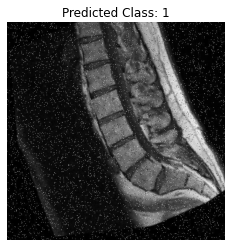

In [4]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Load the trained model
model = tf.keras.models.load_model('x_model.h5')

# Function to preprocess the input image
def preprocess_image(image_path, target_size=(256, 256)):
    """
    Preprocess the image to match the input size of the model.
    """
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to RGB
    image = cv2.resize(image, target_size)  # Resize to match model input
    image = np.expand_dims(image, axis=0)  # Add batch dimension
    image = image / 255.0  # Normalize pixel values
    return image

# Main script
if __name__ == "__main__":
    # Specify the path to the input image
    image_path = 'C:/Users/verti/Documents/spine/newdataset/test/abnormal/007.jpg'  # Replace with the actual path to the input image

    # Preprocess the image
    input_image = preprocess_image(image_path)

    # Make predictions using the model
    predictions = model.predict(input_image)

    # Check the shape of the predictions
    print(f"Predictions shape: {predictions.shape}")

    if len(predictions.shape) == 2:  # Classification case
        # Get the predicted class
        predicted_class = np.argmax(predictions[0])
        print(f"Predicted Class: {predicted_class}")

        # Display the original image
        original_image = cv2.imread(image_path)
        original_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)

        plt.title(f"Predicted Class: {predicted_class}")
        plt.imshow(original_image)
        plt.axis("off")
        plt.show()

    elif len(predictions.shape) == 4:  # Segmentation case
        # Extract segmentation mask
        segmentation_mask = predictions[0, :, :, 0]  # Adjust based on output shape

        # Resize segmentation mask to match the original image size
        original_image = cv2.imread(image_path)
        original_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
        segmentation_mask = cv2.resize(segmentation_mask, (original_image.shape[1], original_image.shape[0]))

        # Overlay the segmentation mask
        overlay = original_image.copy()
        overlay[segmentation_mask > 0.5] = [255, 0, 0]  # Red color for segmentation areas

        # Plot results
        plt.figure(figsize=(12, 6))
        plt.subplot(1, 2, 1)
        plt.title("Original Image")
        plt.imshow(original_image)
        plt.axis("off")

        plt.subplot(1, 2, 2)
        plt.title("Segmentation Result")
        plt.imshow(overlay)
        plt.axis("off")
        plt.show()

    else:
        print("Unexpected output shape. Check the model output!")


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predictions shape: (1, 2)
Predictions range: min=0.2950848639011383, max=0.7049151659011841
Predictions dtype: float32
Predicted Class: 1


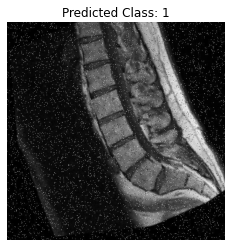

In [10]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Load the trained model
model = tf.keras.models.load_model('x_model.h5')

# Function to preprocess the input image
def preprocess_image(image_path, target_size=(256, 256)):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to RGB
    image = cv2.resize(image, target_size)  # Resize to match model input
    image = np.expand_dims(image, axis=0)  # Add batch dimension
    image = image / 255.0  # Normalize pixel values
    return image

# Function to display segmentation result
def display_segmentation(original_image, segmentation_mask):
    # Resize the segmentation mask to the original image size
    segmentation_mask = cv2.resize(segmentation_mask, (original_image.shape[1], original_image.shape[0]), interpolation=cv2.INTER_NEAREST)

    # Overlay the segmentation mask on the original image
    overlay = original_image.copy()
    overlay[segmentation_mask > 0] = [255, 0, 0]  # Red color for segmentation areas

    # Display results
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.title("Original Image")
    plt.imshow(original_image)
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.title("Segmentation Result")
    plt.imshow(overlay)
    plt.axis("off")
    plt.show()

# Main script
if __name__ == "__main__":
    image_path = 'C:/Users/verti/Documents/spine/newdataset/test/abnormal/007.jpg'

    # Preprocess the input image
    input_image = preprocess_image(image_path)

    # Get predictions from the model
    predictions = model.predict(input_image)

    # Debugging output
    print(f"Predictions shape: {predictions.shape}")
    print(f"Predictions range: min={np.min(predictions)}, max={np.max(predictions)}")
    print(f"Predictions dtype: {predictions.dtype}")

    # Read the original image
    original_image = cv2.imread(image_path)
    original_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)

    if len(predictions.shape) == 4:  # Segmentation case
        if predictions.shape[-1] == 1:  # Binary segmentation
            segmentation_mask = predictions[0, :, :, 0]
            segmentation_mask = (segmentation_mask > 0.5).astype(np.uint8)
        else:  # Multi-class segmentation
            segmentation_mask = np.argmax(predictions[0], axis=-1)

        # Debugging mask output
        print(f"Segmentation mask shape: {segmentation_mask.shape}")
        print(f"Unique values in mask: {np.unique(segmentation_mask)}")

        display_segmentation(original_image, segmentation_mask)

    elif len(predictions.shape) == 2:  # Classification case
        predicted_class = np.argmax(predictions[0])
        print(f"Predicted Class: {predicted_class}")

        plt.title(f"Predicted Class: {predicted_class}")
        plt.imshow(original_image)
        plt.axis("off")
        plt.show()

    else:
        print("Unexpected output shape. Check the model!")
